# DiffProtect Colab Runner (Batch — 5 組參數掃描)

這份 notebook 會在 Google Colab GPU 上執行 `joellliu/DiffProtect`，並一次跑 **5 組不同參數** 的對抗保護攻擊，輸出獨立資料夾方便比較。

流程：
1. 開啟 Colab GPU runtime
2. 安裝與修補 DiffProtect 需要的套件
3. 下載 DiffAE checkpoint 與 victim face model 權重
4. 上傳自拍照
5. 對齊臉部到 256×256
6. 準備 target face
7. **批次執行 5 組參數**（在 `EXPERIMENTS` 陣列裡調）
8. 打包所有結果下載

> 注意：DiffProtect 沒有官方 Colab，這份 notebook 會盡量自動化，但 Google Drive 權重連結若被限流，可能需要手動下載後上傳。

## 0. Colab 設定

先到 Colab 選單：`Runtime` -> `Change runtime type` -> `T4 GPU` 或其他 GPU。

In [ ]:
import os, sys, subprocess, textwrap, json, shutil, glob
from pathlib import Path

def run(cmd, check=True):
    print(f'$ {cmd}')
    return subprocess.run(cmd, shell=True, check=check)

try:
    import torch
    print('Python:', sys.version)
    print('Torch:', torch.__version__)
    print('CUDA available:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
    else:
        raise RuntimeError('請先把 Colab runtime 切到 GPU。')
except Exception as exc:
    raise RuntimeError('GPU 檢查失敗，請確認 Colab runtime 已啟用 GPU。') from exc

## 1. 下載 DiffProtect 原始碼

In [ ]:
%cd /content
!rm -rf DiffProtect
!git clone https://github.com/joellliu/DiffProtect.git
%cd /content/DiffProtect
!git rev-parse --short HEAD

## 2. 安裝套件

DiffProtect 的原始 `requirements.txt` 釘在很舊的 Python / PyTorch 版本。Colab 目前通常是 Python 3.10/3.11 + 新版 PyTorch，所以這裡保留 Colab 內建 PyTorch，並安裝其餘依賴與相容性修補。

In [ ]:
!python -m pip install -q --upgrade pip
!python -m pip uninstall -y -q torchtext || true
!python -m pip install -q --force-reinstall --no-cache-dir 'numpy==1.26.4' 'scipy==1.11.4' 'pandas==2.2.2'
!python -m pip install -q --force-reinstall --no-cache-dir 'opencv-python==4.10.0.84' 'opencv-python-headless==4.10.0.84'
!python -m pip install -q pillow tqdm gdown requests dlib
!python -m pip install -q --force-reinstall --no-cache-dir advertorch
!python -m pip install -q pytorch-lightning==1.4.5 torchmetrics==0.5.0 pytorch-fid==0.2.0 lpips==0.1.4 lmdb==1.2.1 ftfy regex
!python -m pip install -q --force-reinstall --no-cache-dir 'numpy==1.26.4' 'scipy==1.11.4' 'pandas==2.2.2'
!python -m pip install -q --no-deps facenet-pytorch

# numpy / PyTorch 新版相容性修補，讓舊 checkpoint 和舊套件比較容易載入。
Path('sitecustomize.py').write_text('''
import numpy as _np
for _name, _value in {\"complex\": complex, \"float\": float, \"int\": int, \"bool\": bool}.items():
    if not hasattr(_np, _name):
        setattr(_np, _name, _value)

try:
    import torch as _torch
    import torch.autograd.gradcheck as _gradcheck
    if not hasattr(_gradcheck, \"zero_gradients\"):
        def zero_gradients(inputs):
            if isinstance(inputs, _torch.Tensor):
                if inputs.grad is not None:
                    inputs.grad.detach_()
                    inputs.grad.zero_()
            else:
                for elem in inputs:
                    zero_gradients(elem)
        _gradcheck.zero_gradients = zero_gradients
except Exception:
    pass
'''.strip() + '\
')

# advertorch 0.2 會匯入新版 PyTorch 已移除的 zero_gradients；直接 patch site-packages，讓 subprocess 也生效。
import sysconfig
site_packages = Path(sysconfig.get_paths()['purelib'])
advertorch_dir = site_packages / 'advertorch'
zero_gradients_patch = """try:
    from torch.autograd.gradcheck import zero_gradients
except ImportError:
    import torch
    def zero_gradients(inputs):
        if isinstance(inputs, torch.Tensor):
            if inputs.grad is not None:
                inputs.grad.detach_()
                inputs.grad.zero_()
        else:
            for elem in inputs:
                zero_gradients(elem)"""
if advertorch_dir.exists():
    for patch_file in advertorch_dir.rglob('*.py'):
        text = patch_file.read_text()
        old = 'from torch.autograd.gradcheck import zero_gradients'
        if old in text:
            lines = text.splitlines()
            fixed_lines = []
            for line in lines:
                if old in line:
                    indent = line[:len(line) - len(line.lstrip())]
                    fixed_lines.extend(indent + patch_line if patch_line else patch_line for patch_line in zero_gradients_patch.splitlines())
                else:
                    fixed_lines.append(line)
            patch_file.write_text('\n'.join(fixed_lines) + '\n')
            print('Patched advertorch:', patch_file)

# 不在目前 notebook kernel import advertorch；pip 更換 numpy 後，舊 kernel 可能還保留 ABI 不相容狀態。
# demo.py 會用新的 Python subprocess 載入修補後的套件。
validation = subprocess.run(
    "python - <<'PY'\nfrom advertorch.utils import clamp\nimport numpy as np\nprint('advertorch subprocess import ok; numpy', np.__version__)\nPY",
    shell=True,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
print(validation.stdout)
if validation.returncode != 0:
    raise RuntimeError('advertorch subprocess import validation failed')

# === 補上 DiffProtect 缺失的 assets/models package ===
# DiffProtect 官方 repo 把 assets/ gitignore，clone 後沒有 irse.py / ir152.py / facenet.py 的 PyTorch class，
# 即使 .pth 權重檔有也無法 load_state_dict。這裡寫入 IR-SE-50 / MobileFaceNet 模型定義
# （改自 TreB1eN/InsightFace_Pytorch，調整 Backbone signature 成 DiffProtect 期望的 (num_layers, drop_ratio, mode)）。
assets_models = Path('assets/models')
assets_models.mkdir(parents=True, exist_ok=True)
(assets_models / '__init__.py').write_text('')

_IRSE_PY = r"""
from torch.nn import Linear, Conv2d, BatchNorm1d, BatchNorm2d, PReLU, ReLU, Sigmoid, Dropout2d, Dropout, AvgPool2d, MaxPool2d, AdaptiveAvgPool2d, Sequential, Module, Parameter
import torch.nn.functional as F
import torch
from collections import namedtuple
import math
import pdb

##################################  Original Arcface Model #############################################################

class Flatten(Module):
    def forward(self, input):
        return input.reshape(input.size(0), -1)

def l2_norm(input,axis=1):
    norm = torch.norm(input,2,axis,True)
    output = torch.div(input, norm)
    return output

class SEModule(Module):
    def __init__(self, channels, reduction):
        super(SEModule, self).__init__()
        self.avg_pool = AdaptiveAvgPool2d(1)
        self.fc1 = Conv2d(
            channels, channels // reduction, kernel_size=1, padding=0 ,bias=False)
        self.relu = ReLU(inplace=True)
        self.fc2 = Conv2d(
            channels // reduction, channels, kernel_size=1, padding=0 ,bias=False)
        self.sigmoid = Sigmoid()

    def forward(self, x):
        module_input = x
        x = self.avg_pool(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return module_input * x

class bottleneck_IR(Module):
    def __init__(self, in_channel, depth, stride):
        super(bottleneck_IR, self).__init__()
        if in_channel == depth:
            self.shortcut_layer = MaxPool2d(1, stride)
        else:
            self.shortcut_layer = Sequential(
                Conv2d(in_channel, depth, (1, 1), stride ,bias=False), BatchNorm2d(depth))
        self.res_layer = Sequential(
            BatchNorm2d(in_channel),
            Conv2d(in_channel, depth, (3, 3), (1, 1), 1 ,bias=False), PReLU(depth),
            Conv2d(depth, depth, (3, 3), stride, 1 ,bias=False), BatchNorm2d(depth))

    def forward(self, x):
        shortcut = self.shortcut_layer(x)
        res = self.res_layer(x)
        return res + shortcut

class bottleneck_IR_SE(Module):
    def __init__(self, in_channel, depth, stride):
        super(bottleneck_IR_SE, self).__init__()
        if in_channel == depth:
            self.shortcut_layer = MaxPool2d(1, stride)
        else:
            self.shortcut_layer = Sequential(
                Conv2d(in_channel, depth, (1, 1), stride ,bias=False), 
                BatchNorm2d(depth))
        self.res_layer = Sequential(
            BatchNorm2d(in_channel),
            Conv2d(in_channel, depth, (3,3), (1,1),1 ,bias=False),
            PReLU(depth),
            Conv2d(depth, depth, (3,3), stride, 1 ,bias=False),
            BatchNorm2d(depth),
            SEModule(depth,16)
            )
    def forward(self,x):
        shortcut = self.shortcut_layer(x)
        res = self.res_layer(x)
        return res + shortcut

class Bottleneck(namedtuple('Block', ['in_channel', 'depth', 'stride'])):
    '''A named tuple describing a ResNet block.'''
    
def get_block(in_channel, depth, num_units, stride = 2):
  return [Bottleneck(in_channel, depth, stride)] + [Bottleneck(depth, depth, 1) for i in range(num_units-1)]

def get_blocks(num_layers):
    if num_layers == 50:
        blocks = [
            get_block(in_channel=64, depth=64, num_units = 3),
            get_block(in_channel=64, depth=128, num_units=4),
            get_block(in_channel=128, depth=256, num_units=14),
            get_block(in_channel=256, depth=512, num_units=3)
        ]
    elif num_layers == 100:
        blocks = [
            get_block(in_channel=64, depth=64, num_units=3),
            get_block(in_channel=64, depth=128, num_units=13),
            get_block(in_channel=128, depth=256, num_units=30),
            get_block(in_channel=256, depth=512, num_units=3)
        ]
    elif num_layers == 152:
        blocks = [
            get_block(in_channel=64, depth=64, num_units=3),
            get_block(in_channel=64, depth=128, num_units=8),
            get_block(in_channel=128, depth=256, num_units=36),
            get_block(in_channel=256, depth=512, num_units=3)
        ]
    return blocks

class Backbone(Module):
    def __init__(self, num_layers, drop_ratio, mode='ir'):
        super(Backbone, self).__init__()
        assert num_layers in [50, 100, 152], 'num_layers should be 50,100, or 152'
        assert mode in ['ir', 'ir_se'], 'mode should be ir or ir_se'
        blocks = get_blocks(num_layers)
        if mode == 'ir':
            unit_module = bottleneck_IR
        elif mode == 'ir_se':
            unit_module = bottleneck_IR_SE
        self.input_layer = Sequential(Conv2d(3, 64, (3, 3), 1, 1 ,bias=False), 
                                      BatchNorm2d(64), 
                                      PReLU(64))
        self.output_layer = Sequential(BatchNorm2d(512), 
                                       Dropout(drop_ratio),
                                       Flatten(),
                                       Linear(512 * 7 * 7, 512),
                                       BatchNorm1d(512))
        modules = []
        for block in blocks:
            for bottleneck in block:
                modules.append(
                    unit_module(bottleneck.in_channel,
                                bottleneck.depth,
                                bottleneck.stride))
        self.body = Sequential(*modules)
    
    def forward(self,x):
        x = self.input_layer(x)
        x = self.body(x)
        x = self.output_layer(x)
        return l2_norm(x)

##################################  MobileFaceNet #############################################################
    
class Conv_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Conv_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
        self.prelu = PReLU(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.prelu(x)
        return x

class Linear_block(Module):
    def __init__(self, in_c, out_c, kernel=(1, 1), stride=(1, 1), padding=(0, 0), groups=1):
        super(Linear_block, self).__init__()
        self.conv = Conv2d(in_c, out_channels=out_c, kernel_size=kernel, groups=groups, stride=stride, padding=padding, bias=False)
        self.bn = BatchNorm2d(out_c)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x

class Depth_Wise(Module):
     def __init__(self, in_c, out_c, residual = False, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=1):
        super(Depth_Wise, self).__init__()
        self.conv = Conv_block(in_c, out_c=groups, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.conv_dw = Conv_block(groups, groups, groups=groups, kernel=kernel, padding=padding, stride=stride)
        self.project = Linear_block(groups, out_c, kernel=(1, 1), padding=(0, 0), stride=(1, 1))
        self.residual = residual
     def forward(self, x):
        if self.residual:
            short_cut = x
        x = self.conv(x)
        x = self.conv_dw(x)
        x = self.project(x)
        if self.residual:
            output = short_cut + x
        else:
            output = x
        return output

class Residual(Module):
    def __init__(self, c, num_block, groups, kernel=(3, 3), stride=(1, 1), padding=(1, 1)):
        super(Residual, self).__init__()
        modules = []
        for _ in range(num_block):
            modules.append(Depth_Wise(c, c, residual=True, kernel=kernel, padding=padding, stride=stride, groups=groups))
        self.model = Sequential(*modules)
    def forward(self, x):
        return self.model(x)

class MobileFaceNet(Module):
    def __init__(self, embedding_size):
        super(MobileFaceNet, self).__init__()
        self.conv1 = Conv_block(3, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1))
        self.conv2_dw = Conv_block(64, 64, kernel=(3, 3), stride=(1, 1), padding=(1, 1), groups=64)
        self.conv_23 = Depth_Wise(64, 64, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=128)
        self.conv_3 = Residual(64, num_block=4, groups=128, kernel=(3, 3), stride=(1, 1), padding=(1, 1))
        self.conv_34 = Depth_Wise(64, 128, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=256)
        self.conv_4 = Residual(128, num_block=6, groups=256, kernel=(3, 3), stride=(1, 1), padding=(1, 1))
        self.conv_45 = Depth_Wise(128, 128, kernel=(3, 3), stride=(2, 2), padding=(1, 1), groups=512)
        self.conv_5 = Residual(128, num_block=2, groups=256, kernel=(3, 3), stride=(1, 1), padding=(1, 1))
        self.conv_6_sep = Conv_block(128, 512, kernel=(1, 1), stride=(1, 1), padding=(0, 0))
        self.conv_6_dw = Linear_block(512, 512, groups=512, kernel=(7,7), stride=(1, 1), padding=(0, 0))
        self.conv_6_flatten = Flatten()
        self.linear = Linear(512, embedding_size, bias=False)
        self.bn = BatchNorm1d(embedding_size)
    
    def forward(self, x):
        out = self.conv1(x)

        out = self.conv2_dw(out)

        out = self.conv_23(out)

        out = self.conv_3(out)
        
        out = self.conv_34(out)

        out = self.conv_4(out)

        out = self.conv_45(out)

        out = self.conv_5(out)

        out = self.conv_6_sep(out)

        out = self.conv_6_dw(out)

        out = self.conv_6_flatten(out)

        out = self.linear(out)

        out = self.bn(out)
        return l2_norm(out)

##################################  Arcface head #############################################################


"""
(assets_models / 'irse.py').write_text(_IRSE_PY)

# ir152.py / facenet.py 我們暫時不會用，但 attack_utils.py 會 import；給最小 stub
(assets_models / 'ir152.py').write_text('class IR_152:\n    pass\n')
(assets_models / 'facenet.py').write_text(
    'class InceptionResnetV1:\n'
    '    def __init__(self, *a, **k): raise NotImplementedError("facenet.py stub - not implemented")\n'
)
print('Wrote assets/models/{irse.py, ir152.py(stub), facenet.py(stub), __init__.py}')


# torch 2.6+ 的 torch.load 預設 weights_only=True，舊 Lightning checkpoint 需要關掉。
demo_path = Path('demo.py')
demo_text = demo_path.read_text()
demo_text = demo_text.replace("torch.load(f'checkpoints/{conf.name}/last.ckpt', map_location='cpu')", "torch.load(f'checkpoints/{conf.name}/last.ckpt', map_location='cpu', weights_only=False)")
demo_path.write_text(demo_text)

# (mobile_face InceptionResnetV1 fallback 已移除：assets/models/irse.py 已寫入，原本路徑可用)

validation = subprocess.run(
    "python - <<'PY'\nimport attack_utils\nprint('attack_utils import ok')\nPY",
    shell=True,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
)
print(validation.stdout)
if validation.returncode != 0:
    raise RuntimeError('attack_utils import validation failed')

print('Dependencies installed and compatibility patches applied.')

## 3. 下載模型權重

需要兩組權重：
- DiffAE `ffhq256_autoenc/last.ckpt`
- DiffProtect victim face models

如果 Google Drive 被限流，這格可能失敗。失敗時請照下一格的手動上傳方式。

In [ ]:
from pathlib import Path
import shutil
Path('checkpoints/ffhq256_autoenc').mkdir(parents=True, exist_ok=True)
Path('assets/models').mkdir(parents=True, exist_ok=True)

def normalize_victim_model_paths():
    expected = ['mobile_face.pth', 'ir152.pth', 'irse50.pth', 'facenet.pth']
    models_dir = Path('assets/models')
    models_dir.mkdir(parents=True, exist_ok=True)
    search_roots = [Path('assets'), Path('/content')]

    for filename in expected:
        dst = models_dir / filename
        if dst.exists():
            continue
        matches = []
        for root in search_roots:
            if root.exists():
                matches.extend([p for p in root.rglob(filename) if p.is_file()])
        if matches:
            src = matches[0]
            if src.resolve() != dst.resolve():
                shutil.copy2(src, dst)
                print(f'Copied {src} -> {dst}')

    return {name: (models_dir / name).exists() for name in expected}

# DiffAE FFHQ256 autoencoder checkpoint folder
if not Path('checkpoints/ffhq256_autoenc/last.ckpt').exists():
    run("gdown --folder 'https://drive.google.com/drive/folders/1-5zfxT6Gl-GjxM7z9ZO2AHlB70tfmF6V' -O checkpoints/ffhq256_autoenc --remaining-ok", check=False)

# Victim model weights from DiffProtect README
if not Path('assets/models/mobile_face.pth').exists():
    run('rm -rf /content/diffprotect_assets_extract')
    run('mkdir -p /content/diffprotect_assets_extract')
    run("gdown --fuzzy 'https://drive.google.com/file/d/19_Y0jR789BGciogjjoGtWNEv-5QBiCB7/view?usp=sharing' -O /content/diffprotect_assets.zip", check=False)
    if Path('/content/diffprotect_assets.zip').exists():
        run('unzip -q -o /content/diffprotect_assets.zip -d /content/diffprotect_assets_extract', check=False)
        run('cp -R /content/diffprotect_assets_extract/* assets/ 2>/dev/null || true', check=False)
    else:
        print('victim model zip 沒有下載成功，可能是 Google Drive 限流或權限問題。')

model_status = normalize_victim_model_paths()
print('Victim model status:', model_status)

print('DiffAE checkpoint exists:', Path('checkpoints/ffhq256_autoenc/last.ckpt').exists())
print('MobileFaceNet weight exists:', Path('assets/models/mobile_face.pth').exists())

if not Path('assets/models/mobile_face.pth').exists():
    print('找不到 mobile_face.pth。請先看上方 gdown/unzip 是否失敗；若 Google Drive 限流，請改跑下一格手動上傳 victim models zip。')

### 如果自動下載失敗，手動上傳權重

只有在上一格失敗時才需要跑這格。

- 把 DiffAE 的 `last.ckpt` 上傳，會放到 `checkpoints/ffhq256_autoenc/last.ckpt`
- 把 victim model zip 上傳，會解壓到 `assets/`

In [ ]:
RUN_MANUAL_WEIGHT_UPLOAD = False  # 自動下載失敗時改成 True 再跑這格

if RUN_MANUAL_WEIGHT_UPLOAD:
    from google.colab import files
    print('請上傳 DiffAE last.ckpt')
    uploaded = files.upload()
    for name in uploaded:
        if name.endswith('.ckpt'):
            Path('checkpoints/ffhq256_autoenc').mkdir(parents=True, exist_ok=True)
            shutil.move(name, 'checkpoints/ffhq256_autoenc/last.ckpt')

    print('請上傳 victim models zip')
    uploaded = files.upload()
    for name in uploaded:
        if name.endswith('.zip'):
            run(f'rm -rf /content/diffprotect_manual_assets_extract && mkdir -p /content/diffprotect_manual_assets_extract')
            run(f'unzip -q -o {name} -d /content/diffprotect_manual_assets_extract')
            run('cp -R /content/diffprotect_manual_assets_extract/* assets/ 2>/dev/null || true')
            if 'normalize_victim_model_paths' in globals():
                print('Victim model status:', normalize_victim_model_paths())

print('DiffAE checkpoint exists:', Path('checkpoints/ffhq256_autoenc/last.ckpt').exists())
print('MobileFaceNet weight exists:', Path('assets/models/mobile_face.pth').exists())

## 4. 上傳自拍照

可以一次上傳多張。建議使用正臉、清楚、單人照片。

In [ ]:
from google.colab import files
from pathlib import Path
import shutil

raw_dir = Path('/content/diffprotect_input_raw')
aligned_dir = Path('/content/diffprotect_input_aligned')
raw_dir.mkdir(parents=True, exist_ok=True)
aligned_dir.mkdir(parents=True, exist_ok=True)

uploaded = files.upload()
for name in uploaded:
    suffix = Path(name).suffix.lower()
    if suffix in ['.jpg', '.jpeg', '.png', '.webp']:
        shutil.move(name, raw_dir / name)

print('Uploaded images:')
for p in sorted(raw_dir.glob('*')):
    print('-', p.name)

## 5. 對齊臉部到 256x256

DiffProtect / DiffAE 預期輸入是 FFHQ 風格的 256x256 對齊臉。

這格會先使用 DiffProtect 原本的 dlib/FFHQ 對齊；如果偵測不到臉，會自動改用 OpenCV 臉部裁切，最後再用中心裁切保底，避免流程卡住。

In [7]:
import PIL.Image
from pathlib import Path
import shutil

# 1. 修正新版 Pillow 移除 ANTIALIAS 的問題
if not hasattr(PIL.Image, 'ANTIALIAS'):
    PIL.Image.ANTIALIAS = PIL.Image.Resampling.LANCZOS
    print("已手動修補 PIL.Image.ANTIALIAS -> LANCZOS")

# 2. 強制清除並防止 .ipynb_checkpoints 干擾
for kp in [Path('/content/diffprotect_input_aligned'), Path('/content/diffprotect_target_aligned')]:
    checkpoint_dir = kp / '.ipynb_checkpoints'
    if checkpoint_dir.exists():
        shutil.rmtree(checkpoint_dir)
        print(f"已清除隱藏暫存資料夾: {checkpoint_dir}")

已手動修補 PIL.Image.ANTIALIAS -> LANCZOS


In [ ]:
!python align.py -i /content/diffprotect_input_raw -o /content/diffprotect_input_aligned || true

from PIL import Image, ImageOps
import cv2
import numpy as np

def fallback_align_image(src_path, dst_path):
    img = Image.open(src_path).convert('RGB')
    img = ImageOps.exif_transpose(img)
    w, h = img.size

    arr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(arr, cv2.COLOR_BGR2GRAY)
    detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    faces = detector.detectMultiScale(gray, scaleFactor=1.08, minNeighbors=3, minSize=(40, 40))

    if len(faces):
        x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])
        side = int(max(fw, fh) * 2.4)
        cx = x + fw / 2
        cy = y + fh * 0.55
        print(f'Fallback face crop: {src_path.name}, face=({x}, {y}, {fw}, {fh})')
    else:
        side = min(w, h)
        cx = w / 2
        cy = h / 2
        print(f'Fallback center crop: {src_path.name} (OpenCV 也沒有偵測到臉)')

    side = max(64, min(side, max(w, h)))
    left = int(round(cx - side / 2))
    top = int(round(cy - side / 2))
    right = left + side
    bottom = top + side

    pad_left = max(0, -left)
    pad_top = max(0, -top)
    pad_right = max(0, right - w)
    pad_bottom = max(0, bottom - h)
    if any([pad_left, pad_top, pad_right, pad_bottom]):
        img = ImageOps.expand(img, (pad_left, pad_top, pad_right, pad_bottom), fill=(0, 0, 0))
        left += pad_left
        top += pad_top
        right += pad_left
        bottom += pad_top

    crop = img.crop((left, top, right, bottom)).resize((256, 256), Image.Resampling.LANCZOS)
    crop.save(dst_path)

aligned = sorted(Path('/content/diffprotect_input_aligned').glob('*'))
if not aligned:
    print('dlib/FFHQ 對齊沒有輸出，改用 fallback crop 產生 256x256 輸入。')
    aligned_dir.mkdir(parents=True, exist_ok=True)
    for src in sorted(raw_dir.glob('*')):
        if src.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
            dst = aligned_dir / f'{src.stem}.png'
            fallback_align_image(src, dst)
    aligned = sorted(Path('/content/diffprotect_input_aligned').glob('*'))

print('Aligned images:', len(aligned))
for p in aligned:
    print('-', p.name)

if not aligned:
    raise RuntimeError('沒有產生任何 256x256 輸入圖。請確認上傳的是 jpg/png/webp 照片。')

## 5b. 用 InsightFace 5 點 landmark 重新對齊（覆寫上一步輸出）

上一格的 fallback 路徑（dlib 失敗時用 Haar cascade）只做了**裁切沒有旋轉對齊**，眼睛/嘴巴的相對位置不固定。

這一格用 InsightFace 的 SCRFD 偵測 5 點 landmark（左眼、右眼、鼻、左嘴角、右嘴角），擬合相似變換（scale + rotate + translate）把 5 點對到固定的 256×256 模板上，然後把結果寫回 `diffprotect_input_aligned/`，覆寫上一格輸出。

模板用 ArcFace 5 點 × (256/112) 放大版，並向下平移 24 px 加 FFHQ 風格的頭頂留白。對齊效果不理想時可調整 `DST_256` 常數。

target face（cell 6 產生）也會一併用相同邏輯對齊。

numpy: 1.26.4
Source 對齊完成: ok=1, skip=0


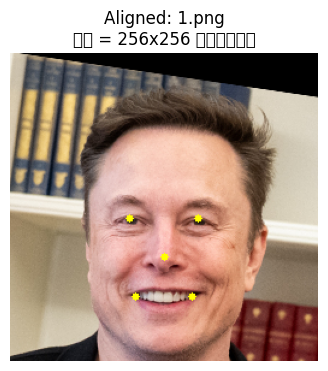

In [11]:
# 只裝 insightface 和 onnxruntime-gpu 本體，--no-deps 避免動到 cell 6 已設好的 numpy 1.26.4
!python -m pip install -q --no-deps insightface==0.7.3 2>&1 | tail -3
!python -m pip install -q --no-deps onnxruntime-gpu==1.19.2 2>&1 | tail -3
# insightface 真正要 import 但被 --no-deps 擋掉的：onnx、easydict
!python -m pip install -q --no-deps onnx==1.16.1 easydict 2>&1 | tail -3
# onnx 1.16 需要 protobuf 4.25.x
!python -m pip install -q 'protobuf>=4.25,<5' 2>&1 | tail -3

# 重要：不要 reload numpy/scipy/skimage（cv2 認不出新版 ndarray，會 raise cvtColor error）
# 只清掉 insightface 和 albumentations 即可，讓它們重新 import 看到 stub 後的 albumentations
import sys, types
for name in list(sys.modules):
    if name.split('.')[0] in {'insightface', 'albumentations'}:
        del sys.modules[name]

# === stub 假的 albumentations package（避免 numpy 1.26 + alb 1.4 的 KeyError）===
_alb = types.ModuleType('albumentations')
_alb.__path__ = []
_alb.__version__ = '0.0.0-stub'
_alb.Compose = lambda *a, **k: (lambda **kk: kk)

_alb_core = types.ModuleType('albumentations.core'); _alb_core.__path__ = []
_alb_ti = types.ModuleType('albumentations.core.transforms_interface')

class _StubImageOnlyTransform:
    def __init__(self, *a, **k): pass
    def __call__(self, **kw): return kw

_alb_ti.ImageOnlyTransform = _StubImageOnlyTransform
_alb_ti.DualTransform = _StubImageOnlyTransform

_alb_aug = types.ModuleType('albumentations.augmentations'); _alb_aug.__path__ = []
_alb_pt = types.ModuleType('albumentations.pytorch'); _alb_pt.__path__ = []

sys.modules['albumentations'] = _alb
sys.modules['albumentations.core'] = _alb_core
sys.modules['albumentations.core.transforms_interface'] = _alb_ti
sys.modules['albumentations.augmentations'] = _alb_aug
sys.modules['albumentations.pytorch'] = _alb_pt
_alb.core = _alb_core
_alb_core.transforms_interface = _alb_ti
_alb.augmentations = _alb_aug
_alb.pytorch = _alb_pt
_alb.ImageOnlyTransform = _StubImageOnlyTransform

import numpy as np
import cv2
from pathlib import Path
from PIL import Image, ImageOps

print('numpy:', np.__version__)

# Fail-fast：cell 5b 依賴 cell 6 的 numpy 1.26.4 + scipy 1.11.4 環境
if not np.__version__.startswith('1.26'):
    raise RuntimeError(
        f'numpy 版本錯誤 (現在是 {np.__version__})。\n'
        f'cell 5b 需要 numpy 1.26.4（由 cell 6 安裝）。\n'
        f'解法：Runtime -> Restart session，然後依序跑 cell 2 -> 4 -> 6 -> 8 -> 12 -> 14 -> 15 -> 17。'
    )


def similarity_transform_2d(src, dst):
    """手刻 Umeyama 2D similarity transform，避免 skimage 依賴。"""
    src = np.asarray(src, dtype=np.float64)
    dst = np.asarray(dst, dtype=np.float64)
    n = src.shape[0]
    src_mean = src.mean(axis=0); dst_mean = dst.mean(axis=0)
    src_c = src - src_mean; dst_c = dst - dst_mean
    H = src_c.T @ dst_c
    U, S, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T
    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        S = S.copy(); S[-1] = -S[-1]
        R = Vt.T @ U.T
    var_src = (src_c ** 2).sum() / n
    scale = S.sum() / (n * var_src) if var_src > 0 else 1.0
    t = dst_mean - scale * (R @ src_mean)
    M = np.zeros((2, 3), dtype=np.float32)
    M[:, :2] = scale * R
    M[:, 2] = t
    return M


from insightface.app import FaceAnalysis

# 256x256 對齊模板：ArcFace 5 點 (112 空間) × (256/112)，下移 24 px 加頭頂留白
DST_256 = np.array([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041],
], dtype=np.float32) * (256.0 / 112.0)
DST_256[:, 1] += 24.0
# crop 少一點：把模板向 canvas 中心 (128,128) 縮 0.8 倍，臉變小 → 留更多下巴/頭頂空間
DST_256 = (DST_256 - np.array([128.0, 128.0], dtype=np.float32)) * 0.7 \
          + np.array([128.0, 128.0], dtype=np.float32)

if 'INSIGHT_APP' not in globals():
    INSIGHT_APP = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
    INSIGHT_APP.prepare(ctx_id=0, det_size=(640, 640))


def align_5pt_256(src_path: Path, dst_path: Path) -> bool:
    img = Image.open(src_path).convert('RGB')
    img = ImageOps.exif_transpose(img)
    bgr = cv2.cvtColor(np.ascontiguousarray(np.array(img)), cv2.COLOR_RGB2BGR)
    faces = INSIGHT_APP.get(bgr)
    if not faces:
        print(f'  [skip] InsightFace 偵測不到臉: {src_path.name}')
        return False
    face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
    src_kps = face.kps.astype(np.float32)
    M = similarity_transform_2d(src_kps, DST_256)
    aligned = cv2.warpAffine(bgr, M, (256, 256), borderValue=(0, 0, 0))
    cv2.imwrite(str(dst_path), aligned)
    return True


def align_dir(raw_dir: Path, aligned_dir: Path):
    aligned_dir.mkdir(parents=True, exist_ok=True)
    ok = skip = 0
    for src in sorted(raw_dir.glob('*')):
        if src.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.webp']:
            continue
        dst = aligned_dir / f'{src.stem}.png'
        if align_5pt_256(src, dst):
            ok += 1
        else:
            skip += 1
    return ok, skip


raw_dir = Path('/content/diffprotect_input_raw')
aligned_dir = Path('/content/diffprotect_input_aligned')
ok, skip = align_dir(raw_dir, aligned_dir)
print(f'Source 對齊完成: ok={ok}, skip={skip}')

target_raw = Path('/content/diffprotect_target_raw')
target_aligned = Path('/content/diffprotect_target_aligned')
if target_raw.exists() and any(target_raw.iterdir()):
    ok_t, skip_t = align_dir(target_raw, target_aligned)
    print(f'Target 對齊完成: ok={ok_t}, skip={skip_t}')

import matplotlib.pyplot as plt
samples = sorted(aligned_dir.glob('*.png'))
if samples:
    sample = cv2.imread(str(samples[0]))
    overlay = sample.copy()
    for x, y in DST_256.astype(int):
        cv2.circle(overlay, (x, y), 3, (0, 255, 255), -1)
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f'Aligned: {samples[0].name}\n黃點 = 256x256 模板目標位置')
    plt.axis('off')
    plt.show()

## 6. 準備 target face

DiffProtect 是 targeted attack，需要一張 target face。這份 notebook 會優先使用 DiffProtect asset 裡的預設 target；如果不存在，會下載 NVIDIA FFHQ repo 的公開範例圖，裁一張臉作為 target。

> 若你想要更完整的保護效果，可以把 `USE_CUSTOM_TARGET` 改成 `True`，另外上傳一張 target 臉。

In [ ]:
USE_CUSTOM_TARGET = False

target_path = Path('assets/datasets/target/085807.jpg')
public_target_raw = Path('/content/diffprotect_public_target_raw.png')
public_target_aligned = Path('/content/diffprotect_public_target.png')

if USE_CUSTOM_TARGET:
    from google.colab import files
    custom_raw = Path('/content/diffprotect_target_raw')
    custom_aligned = Path('/content/diffprotect_target_aligned')
    custom_raw.mkdir(parents=True, exist_ok=True)
    custom_aligned.mkdir(parents=True, exist_ok=True)
    print('請上傳一張 target face')
    uploaded = files.upload()
    for name in uploaded:
        suffix = Path(name).suffix.lower()
        if suffix in ['.jpg', '.jpeg', '.png', '.webp']:
            shutil.move(name, custom_raw / name)
    run('python align.py -i /content/diffprotect_target_raw -o /content/diffprotect_target_aligned', check=False)
    targets = sorted(custom_aligned.glob('*'))
    if not targets:
        print('dlib/FFHQ 對齊 target 沒有輸出，改用 fallback crop 產生 256x256 target。')
        for src in sorted(custom_raw.glob('*')):
            if src.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
                dst = custom_aligned / f'{src.stem}.png'
                fallback_align_image(src, dst)
        targets = sorted(custom_aligned.glob('*'))
    if not targets:
        raise RuntimeError('target face 對齊失敗，請換一張清楚正臉照片。')
    target_path = targets[0]
elif not target_path.exists():
    print('找不到 asset 預設 target，改用公開 FFHQ 範例圖裁切 target face。')
    if not public_target_raw.exists():
        run('curl -L https://raw.githubusercontent.com/NVlabs/ffhq-dataset/master/ffhq-teaser.png -o /content/diffprotect_public_target_raw.png')
    fallback_align_image(public_target_raw, public_target_aligned)
    target_path = public_target_aligned

if Path(target_path).resolve() in [p.resolve() for p in sorted(Path('/content/diffprotect_input_aligned').glob('*'))]:
    raise RuntimeError('target_path 不應該和 source 自拍照相同。請設定 USE_CUSTOM_TARGET=True 並上傳 target，或確認公開 target 下載成功。')

print('Target path:', target_path)

## 7. 批次執行 DiffProtect（5 組參數）

定義 `EXPERIMENTS` 陣列，每個元素是一組參數，會依序跑完。每組輸出獨立資料夾 `/content/diffprotect_outputs/<exp_name>/`。

5 組參數預設掃描的軸：
- **eps**：L∞ 擾動上限（0.04 ~ 0.12），越大攻擊越強但越容易肉眼察覺
- **iter**：對抗優化迭代數（30 ~ 150），越多越貼合 target embedding
- **T_enc / T_atk / T_inf**：DDIM 各階段步數
- **attack_models**：surrogate FR 模型

> 目前 surrogate 仍是 `mobile_face`（cell 6 patch 成 facenet-pytorch InceptionResnetV1，28M params）。IRSE50（43M params, 同 R50 級）接好後，可把 `attack_models` 改成 `['irse50']` 或 ensemble `['irse50','ir152']`。
>
> 5 組全跑大約 5×60s ~ 5×3min（看 ITER），總計 5~15 分鐘。

In [ ]:
# ==================== 批次參數陣列 ====================
# 每個 dict 是一組 DiffProtect 執行參數。改這裡就改 5 組設定。
# 重要：T_enc 必須能被 T_atk 整除（demo.py 內部 xT_all 索引用 T_enc//T_atk），否則 IndexError。
#
# 設計思路：根據歷史成功經驗，DiffProtect latent eps 應落在 0.007 ~ 0.025 之間
# （比 pixel PGD 小一個量級）；eps 過大會把臉打到認不出。
# 已改成 IRSE50 (43M, IR-SE-ResNet-50) 作 surrogate，跟 InsightFace ArcFace R50 同架構家族，transfer 應該更好
EXPERIMENTS = [
    # 設計：T_enc=200 / T_inf=200（你歷史成功設定），讓 diffusion 有更多 latent 空間+生成步數
    # 這樣低 eps 也能往深處改而不爆，視覺更乾淨。每組大約 2~3 分鐘。

    # 1) 最小擾動 + 深 T_enc：應該幾乎看不出來，攻擊弱
    {'name': 'exp1_eps0010',  'attack_models': ['irse50'], 'test_models': ['irse50'],
     'eps': 0.010, 'iter': 40, 'T_enc': 200, 'T_atk': 5, 'T_inf': 200},  # 200/5=40

    # 2) 你成功過的 eps=0.015 + Tenc/Tinf=200，iter=40
    {'name': 'exp2_eps0015_i40', 'attack_models': ['irse50'], 'test_models': ['irse50'],
     'eps': 0.015, 'iter': 40, 'T_enc': 200, 'T_atk': 5, 'T_inf': 200},

    # 3) 同 eps，iter 拉到 50（多優化）
    {'name': 'exp3_eps0015_i50', 'attack_models': ['irse50'], 'test_models': ['irse50'],
     'eps': 0.015, 'iter': 50, 'T_enc': 200, 'T_atk': 5, 'T_inf': 200},

    # 4) 你成功過的 eps=0.02 + Tenc/Tinf=200, iter=65
    {'name': 'exp4_eps0020_i65', 'attack_models': ['irse50'], 'test_models': ['irse50'],
     'eps': 0.020, 'iter': 65, 'T_enc': 200, 'T_atk': 5, 'T_inf': 200},

    # 5) 略強 eps=0.025，看是否還能維持構圖（之前 Tenc=100 就崩了，這次給 200 看會不會救回來）
    {'name': 'exp5_eps0025',     'attack_models': ['irse50'], 'test_models': ['irse50'],
     'eps': 0.025, 'iter': 50, 'T_enc': 200, 'T_atk': 5, 'T_inf': 200},

# ======================================================

save_root = Path('/content/diffprotect_outputs')
save_root.mkdir(parents=True, exist_ok=True)
demo_log_dir = Path('/content/diffprotect_logs'); demo_log_dir.mkdir(parents=True, exist_ok=True)

# 防呆檢查：T_enc 必須能被 T_atk 整除
for exp in EXPERIMENTS:
    if exp['T_enc'] % exp['T_atk'] != 0:
        raise ValueError(f"{exp['name']}: T_enc={exp['T_enc']} 不能被 T_atk={exp['T_atk']} 整除，會 IndexError")

# 前置檢查
required_paths = [Path('checkpoints/ffhq256_autoenc/last.ckpt'), Path(target_path)]
if not Path('assets/models/irse50.pth').exists() and 'normalize_victim_model_paths' in globals():
    print('irse50.pth 不在預期位置，嘗試整理已下載/已解壓的權重檔...')
    print('Victim model status:', normalize_victim_model_paths())
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise RuntimeError('缺少必要檔案：\n' + '\n'.join(missing))

source_images = sorted(Path('/content/diffprotect_input_aligned').glob('*'))
if not source_images:
    raise RuntimeError('沒有 aligned source images，請回到「對齊臉部」cell 重跑。')
print('Source images:', [p.name for p in source_images])
print('Target:', target_path)
print(f'\n=== 批次執行 {len(EXPERIMENTS)} 組參數 ===\n')

import time
results_summary = []

for i, exp in enumerate(EXPERIMENTS, 1):
    exp_save_path = save_root / exp['name']
    exp_log_path = demo_log_dir / f"{exp['name']}.log"
    exp_save_path.mkdir(parents=True, exist_ok=True)

    print(f"\n----- [{i}/{len(EXPERIMENTS)}] {exp['name']} -----")
    print(f"  eps={exp['eps']}, iter={exp['iter']}, T_enc={exp['T_enc']}, T_atk={exp['T_atk']}, T_inf={exp['T_inf']}")
    print(f"  attack_models={exp['attack_models']}, test_models={exp['test_models']}")

    cmd = [
        'python demo.py',
        '--source_dir /content/diffprotect_input_aligned',
        f'--save_path {exp_save_path}',
        '--clean_path /content/diffprotect_input_aligned',
        f'--target_path {target_path}',
        f'--test_path {target_path}',
        '--model_names ' + ' '.join(exp['attack_models']),
        '--test_model_names ' + ' '.join(exp['test_models']),
        f"--iter {exp['iter']}",
        f"--T_enc {exp['T_enc']}",
        f"--T_atk {exp['T_atk']}",
        f"--T_inf {exp['T_inf']}",
        f"--eps {exp['eps']}",
    ]
    cmd_str = ' '.join(cmd)
    print(f"  $ {cmd_str}")

    t0 = time.time()
    proc = subprocess.run(cmd_str, shell=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    elapsed = time.time() - t0
    exp_log_path.write_text(proc.stdout)

    tail = proc.stdout.splitlines()[-15:]
    print('\n'.join(tail))
    print(f"  耗時: {elapsed:.1f}s  exit={proc.returncode}  log={exp_log_path}")

    results_summary.append({
        'name': exp['name'],
        'eps': exp['eps'],
        'iter': exp['iter'],
        'exit_code': proc.returncode,
        'elapsed_sec': round(elapsed, 1),
        'save_path': str(exp_save_path),
    })

# 結果總覽
print('\n========== 批次結果總覽 ==========')
for r in results_summary:
    status = 'OK' if r['exit_code'] == 0 else f"FAIL({r['exit_code']})"
    print(f"  {r['name']:30s} eps={r['eps']:.3f} iter={r['iter']:3d}  {status}  {r['elapsed_sec']}s")

(save_root / 'batch_summary.json').write_text(json.dumps(results_summary, indent=2, ensure_ascii=False))
print(f"\n總覽已存：{save_root / 'batch_summary.json'}")

if all(r['exit_code'] != 0 for r in results_summary):
    raise RuntimeError('所有實驗都失敗了，請檢查 logs。')

## 8. 預覽與下載結果

In [ ]:
from IPython.display import display
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt

# 對每個實驗找出 demo.py 產生的 save_eps_*_iter_* 子資料夾，預覽第一張結果
print('=== 每組實驗的對抗保護圖預覽 ===\n')
fig_rows = []

for r in results_summary:
    exp_save = Path(r['save_path'])
    inner_dirs = sorted(exp_save.glob('save_*'))
    if not inner_dirs:
        print(f"  [skip] {r['name']}: 沒有輸出資料夾")
        continue
    inner = inner_dirs[-1]
    pngs = sorted(inner.glob('*.png'))
    if not pngs:
        print(f"  [skip] {r['name']}: 沒有 png")
        continue
    print(f"  {r['name']:30s} eps={r['eps']:.3f} iter={r['iter']:3d}  →  {pngs[0].name}")
    fig_rows.append((r['name'], pngs[0]))

# 並列顯示 5 組結果
if fig_rows:
    fig, axes = plt.subplots(1, len(fig_rows), figsize=(4 * len(fig_rows), 4))
    if len(fig_rows) == 1:
        axes = [axes]
    for ax, (name, p) in zip(axes, fig_rows):
        ax.imshow(Image.open(p))
        ax.set_title(name, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# 把所有實驗輸出 + log + summary 打包成單一 zip
zip_path = '/content/diffprotect_batch_results.zip'
!rm -f {zip_path}
!cd /content && zip -qr {zip_path} diffprotect_outputs diffprotect_logs
print(f"\n打包完成: {zip_path}")
files.download(zip_path)

## 常見問題

- `CUDA available: False`：請切換 Colab GPU runtime 後從頭重跑。
- Google Drive 權重下載失敗：通常是配額或權限問題，改用手動上傳權重那格。
- 臉部對齊失敗：換正臉、清楚、單人照片。
- Colab 記憶體不足：維持 `mobile_face`，降低 `ITER/T_ENC/T_INF`，或改用 Colab Pro GPU。